In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import style
style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df = df.drop('Cabin', axis = 1)

In [8]:
avg_age = df['Age'].mean()
df.Age.replace(np.nan, avg_age, inplace = True)

In [9]:
freq_port = df.Embarked.dropna().mode()[0]
df['Embarked'] = df['Embarked'].fillna(freq_port)

In [10]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# -------------------------------------------------------------------------------------------------------

<Axes: xlabel='Survived', ylabel='count'>

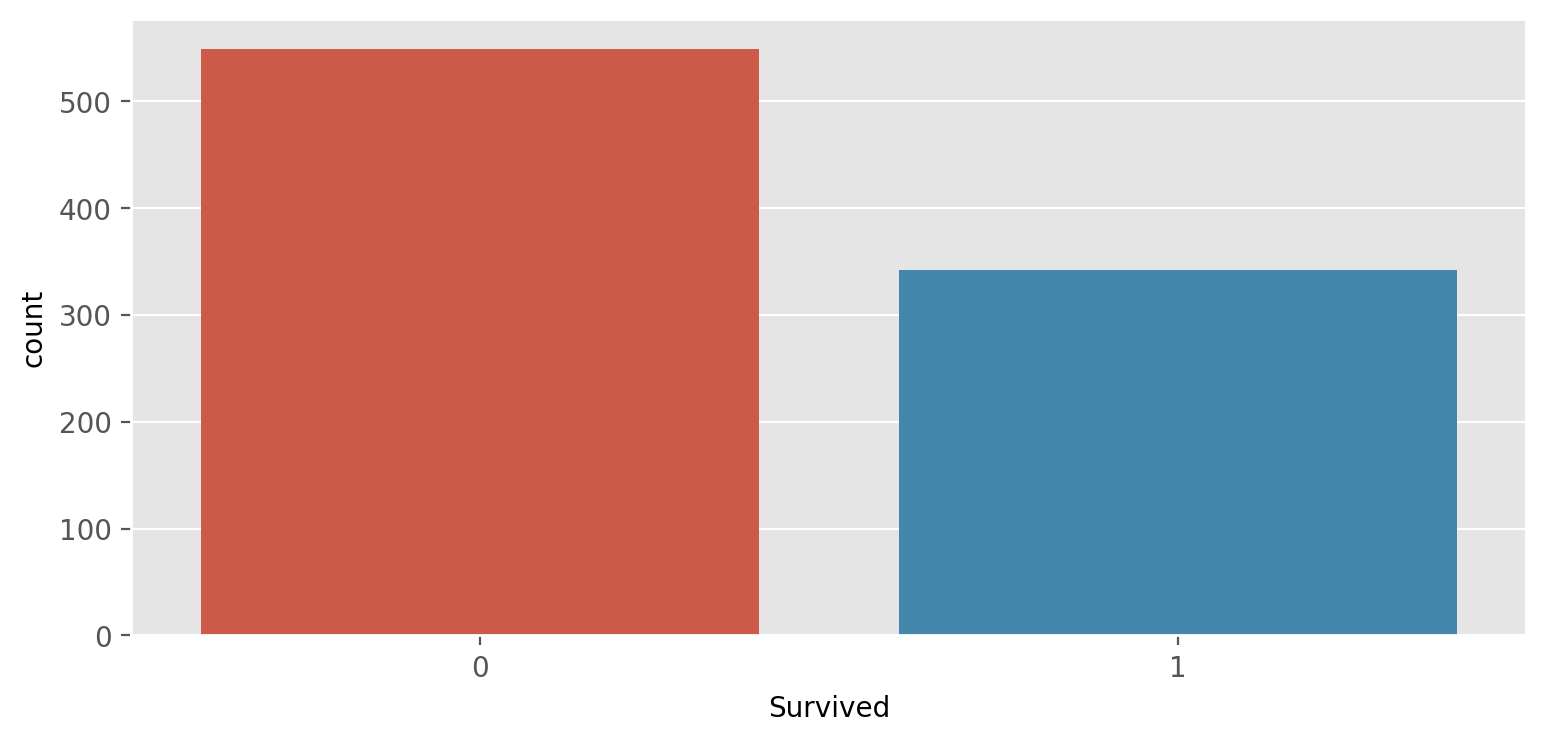

In [11]:
plt.figure(figsize = (9,4), dpi = 200)
sns.countplot(x = 'Survived', data = df)

<Axes: xlabel='Survived', ylabel='count'>

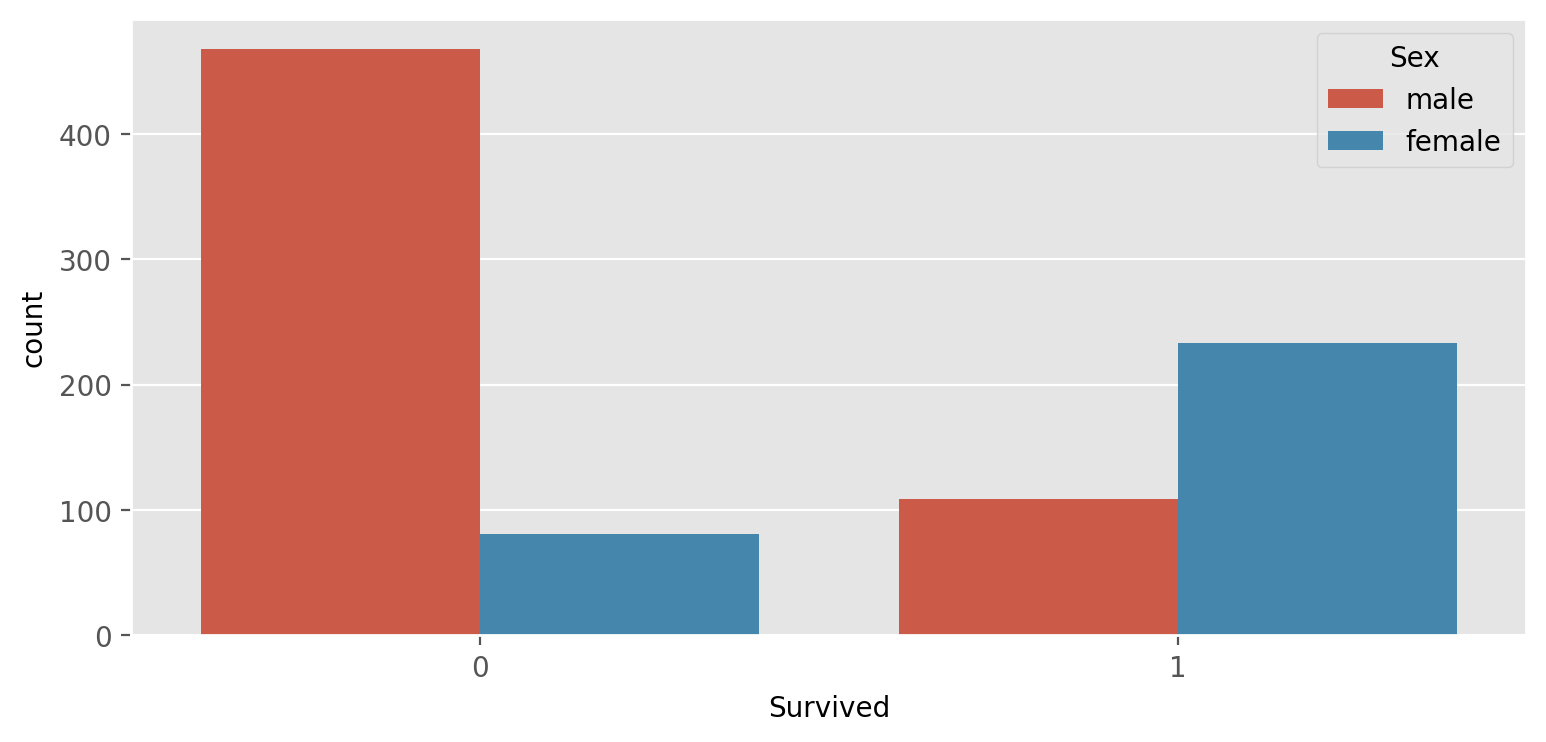

In [12]:
plt.figure(figsize = (9,4), dpi = 200)
sns.countplot(x = 'Survived', hue = 'Sex', data = df)

In [13]:
df.groupby(['Sex'])['Survived'].value_counts(normalize = True)

Sex     Survived
female  1           0.742038
        0           0.257962
male    0           0.811092
        1           0.188908
Name: Survived, dtype: float64

<Axes: xlabel='Survived', ylabel='count'>

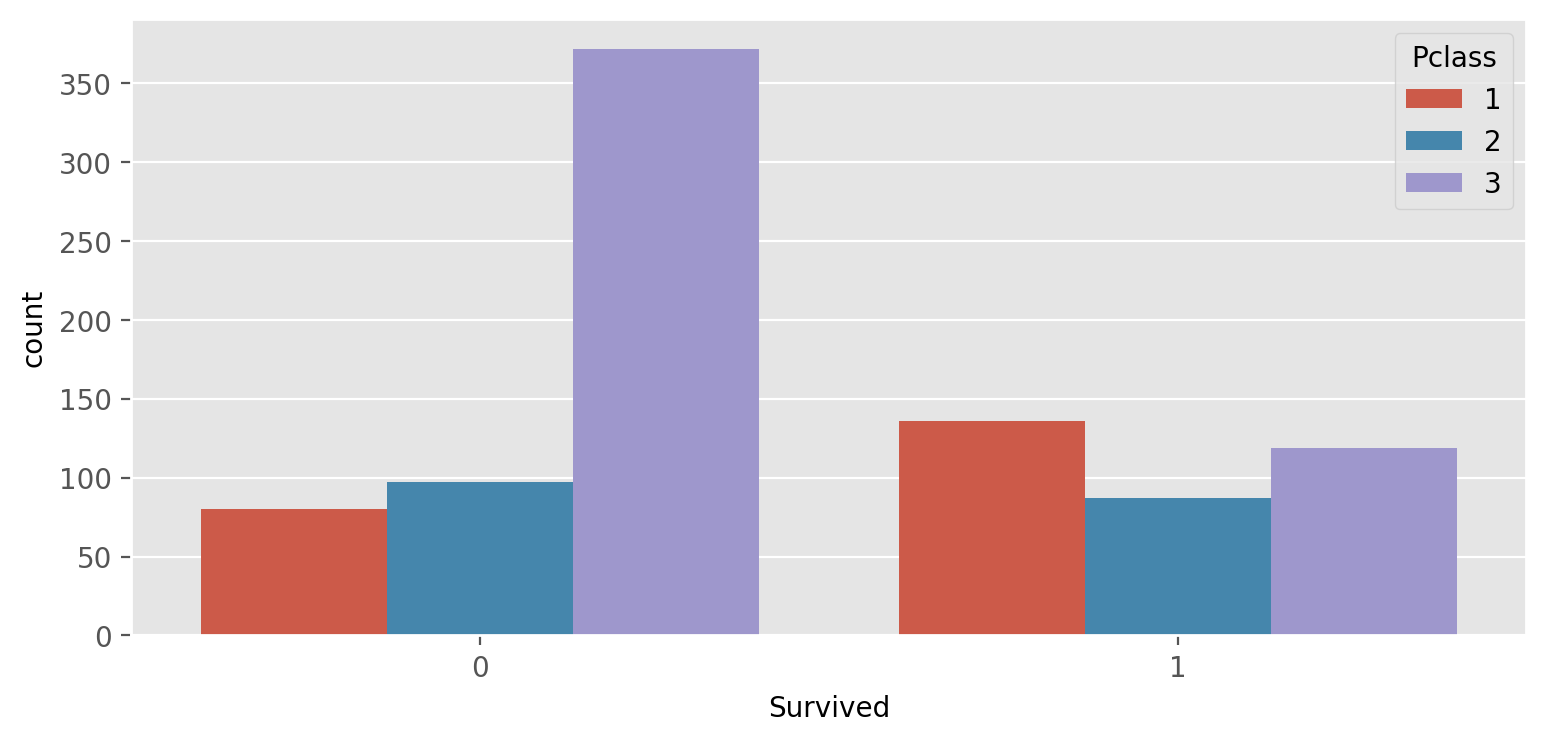

In [14]:
plt.figure(figsize = (9,4), dpi = 200)
sns.countplot(x = 'Survived', hue = 'Pclass',data = df)

In [15]:
df.groupby(['Pclass'])['Survived'].value_counts(normalize = True)

Pclass  Survived
1       1           0.629630
        0           0.370370
2       0           0.527174
        1           0.472826
3       0           0.757637
        1           0.242363
Name: Survived, dtype: float64

<Axes: xlabel='Survived', ylabel='count'>

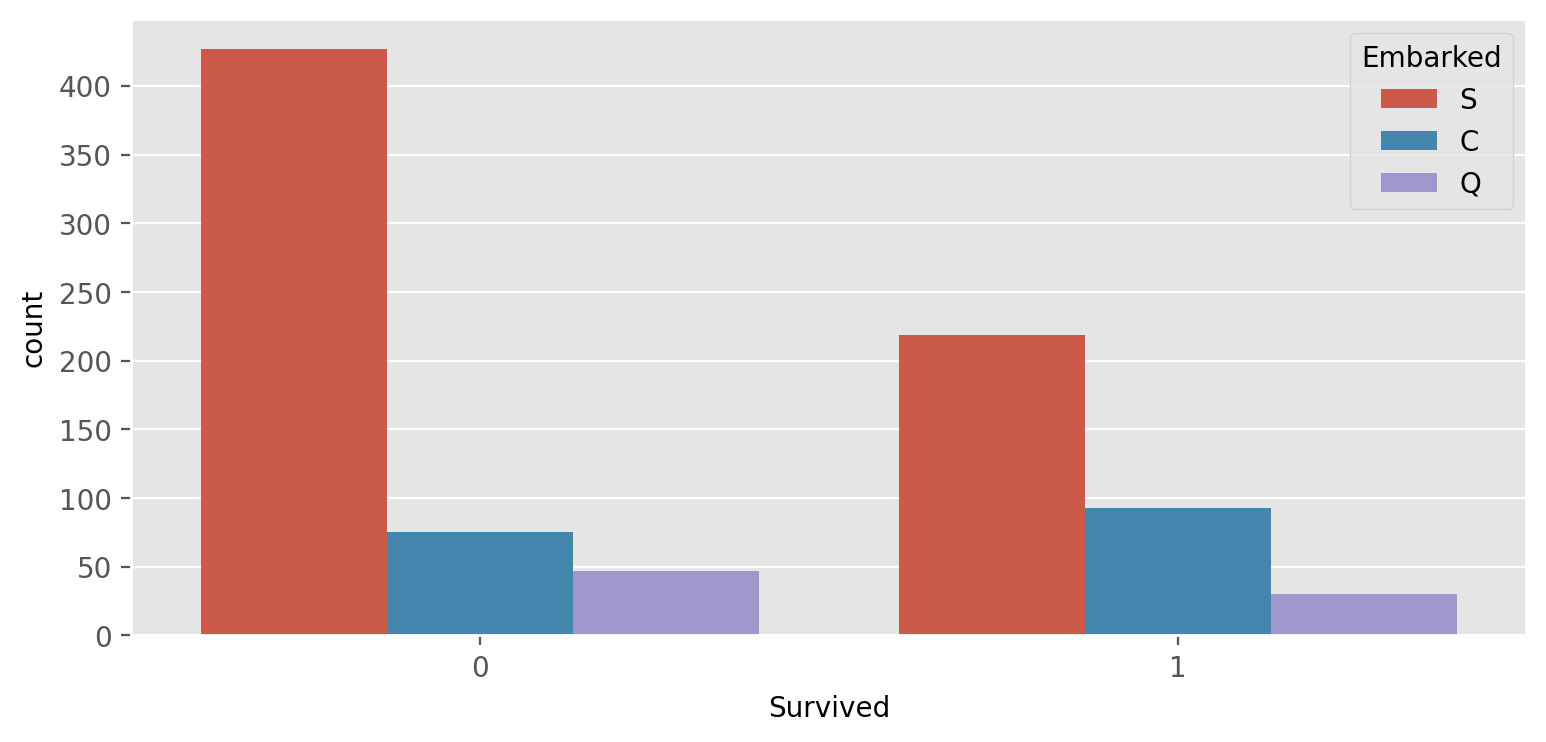

In [16]:
plt.figure(figsize = (9,4), dpi = 200)
sns.countplot(x = 'Survived', hue = 'Embarked', data = df)

In [17]:
df.groupby(['Embarked'])['Survived'].value_counts(normalize = True)

Embarked  Survived
C         1           0.553571
          0           0.446429
Q         0           0.610390
          1           0.389610
S         0           0.660991
          1           0.339009
Name: Survived, dtype: float64

<Axes: xlabel='Survived', ylabel='Age'>

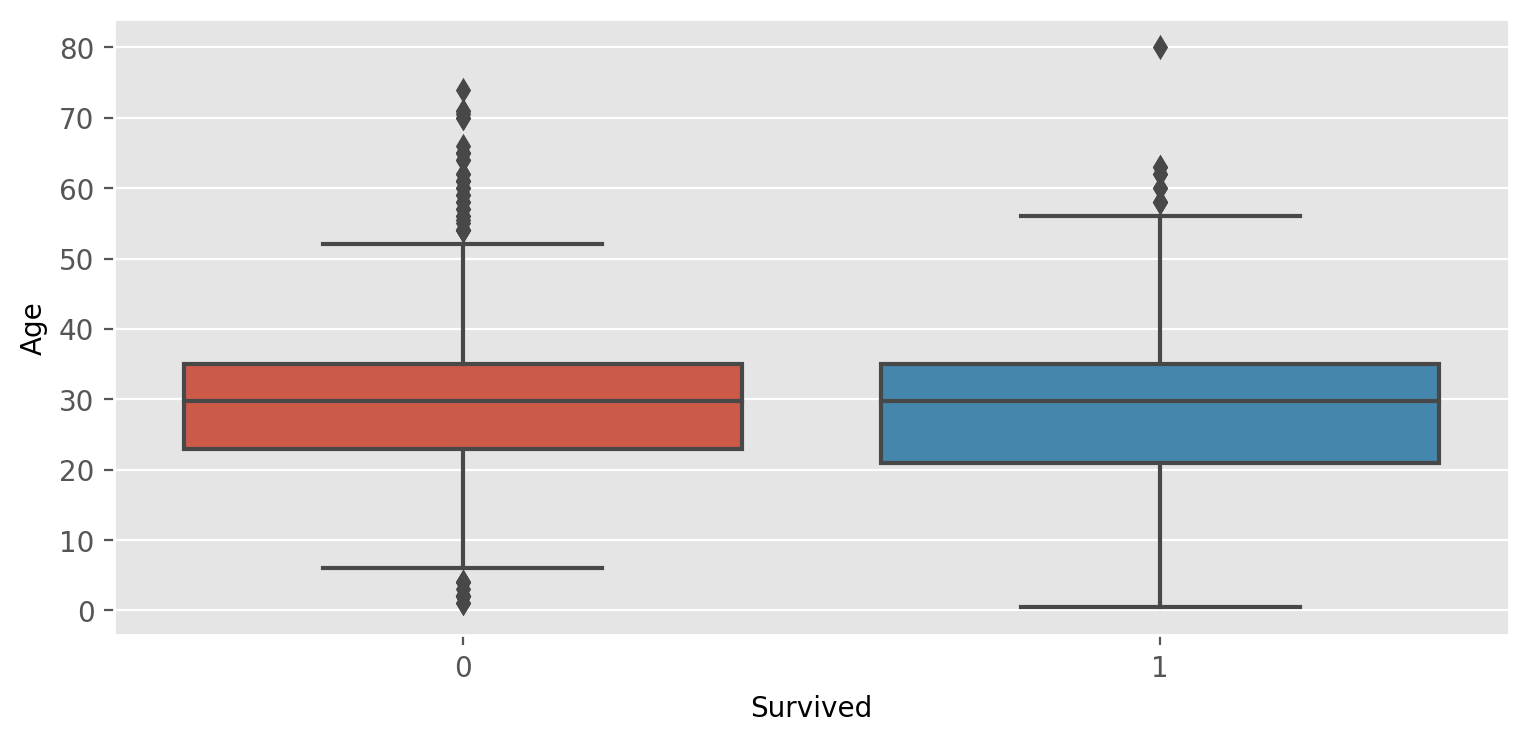

In [18]:
plt.figure(figsize = (9,4), dpi = 200)
sns.boxplot(x = 'Survived', y = 'Age', data = df)

<Axes: xlabel='Survived', ylabel='Age'>

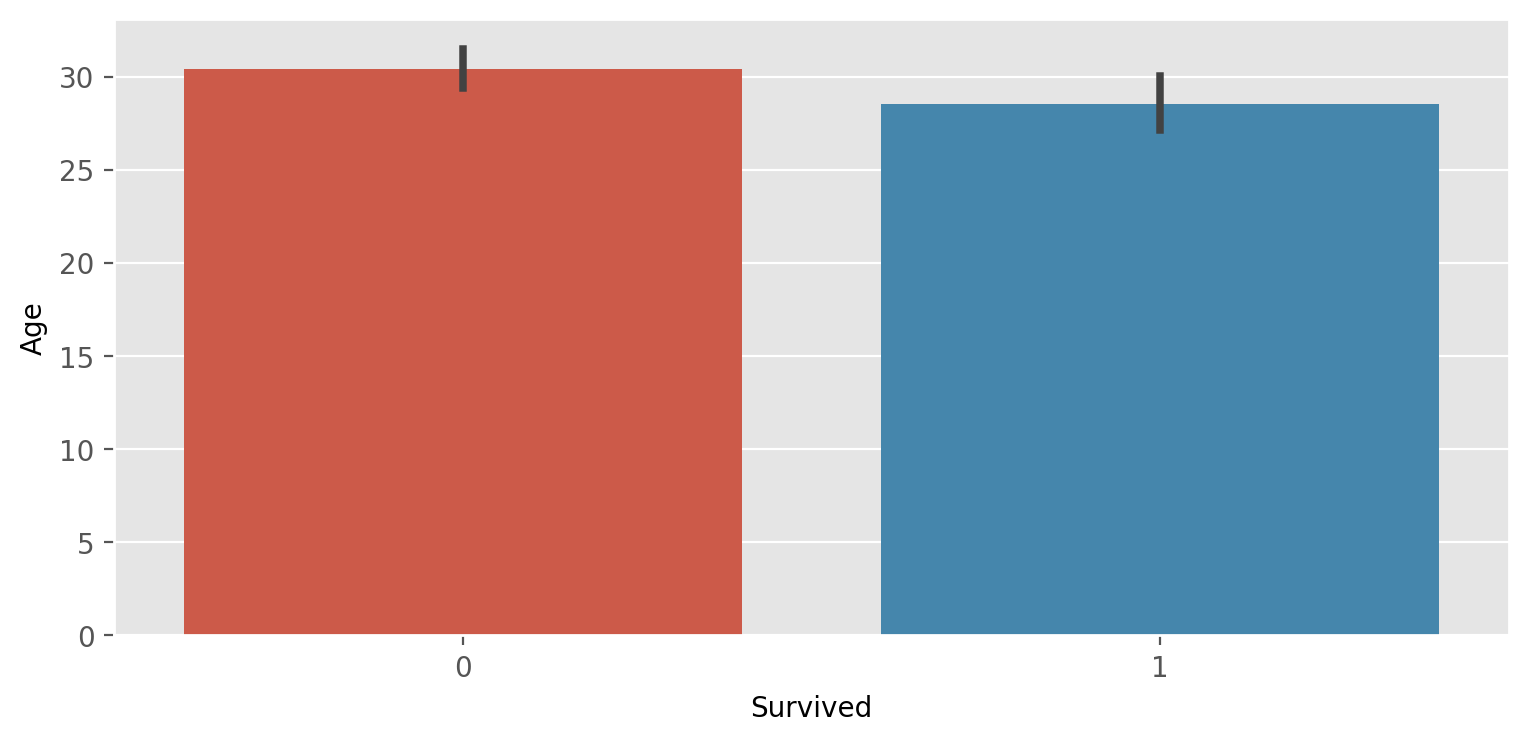

In [19]:
plt.figure(figsize = (9,4), dpi = 200)
sns.barplot(x = 'Survived', y = 'Age', data = df)

<Axes: xlabel='Survived', ylabel='Fare'>

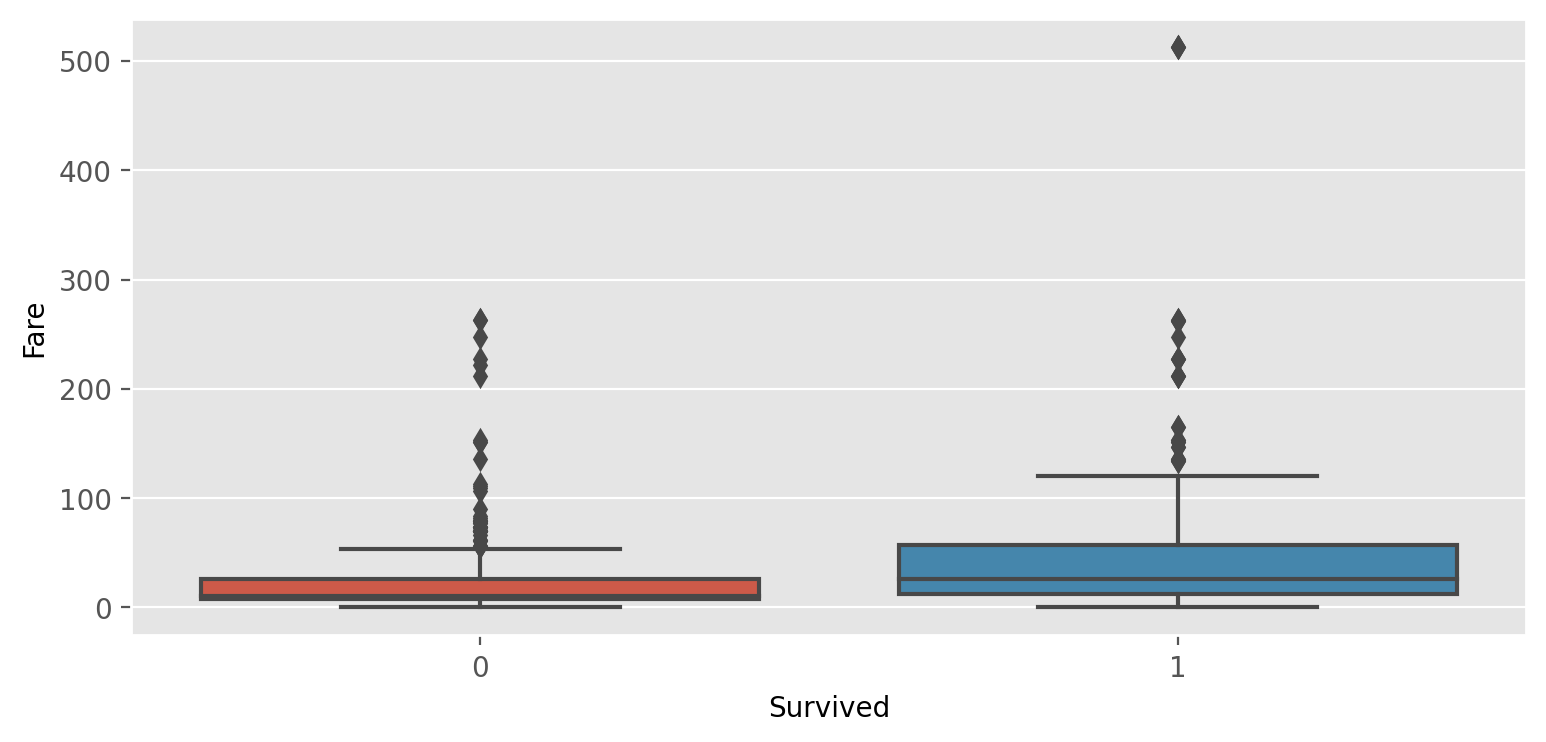

In [20]:
plt.figure(figsize = (9,4), dpi = 200)
sns.boxplot(x = 'Survived', y = 'Fare', data = df)

<Axes: xlabel='Survived', ylabel='Fare'>

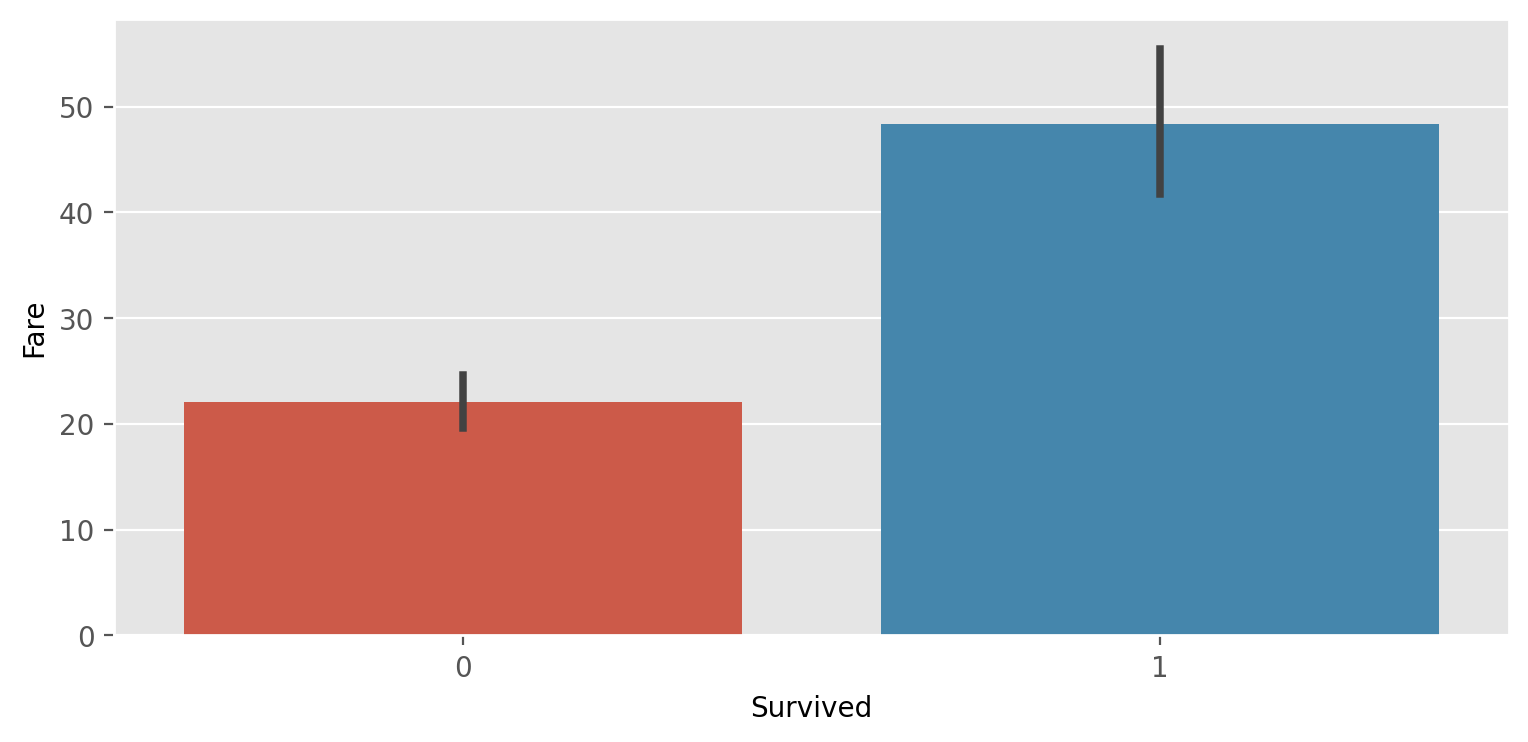

In [21]:
plt.figure(figsize = (9,4), dpi = 200)
sns.barplot(x = 'Survived', y = 'Fare', data = df)

<Axes: xlabel='Survived', ylabel='count'>

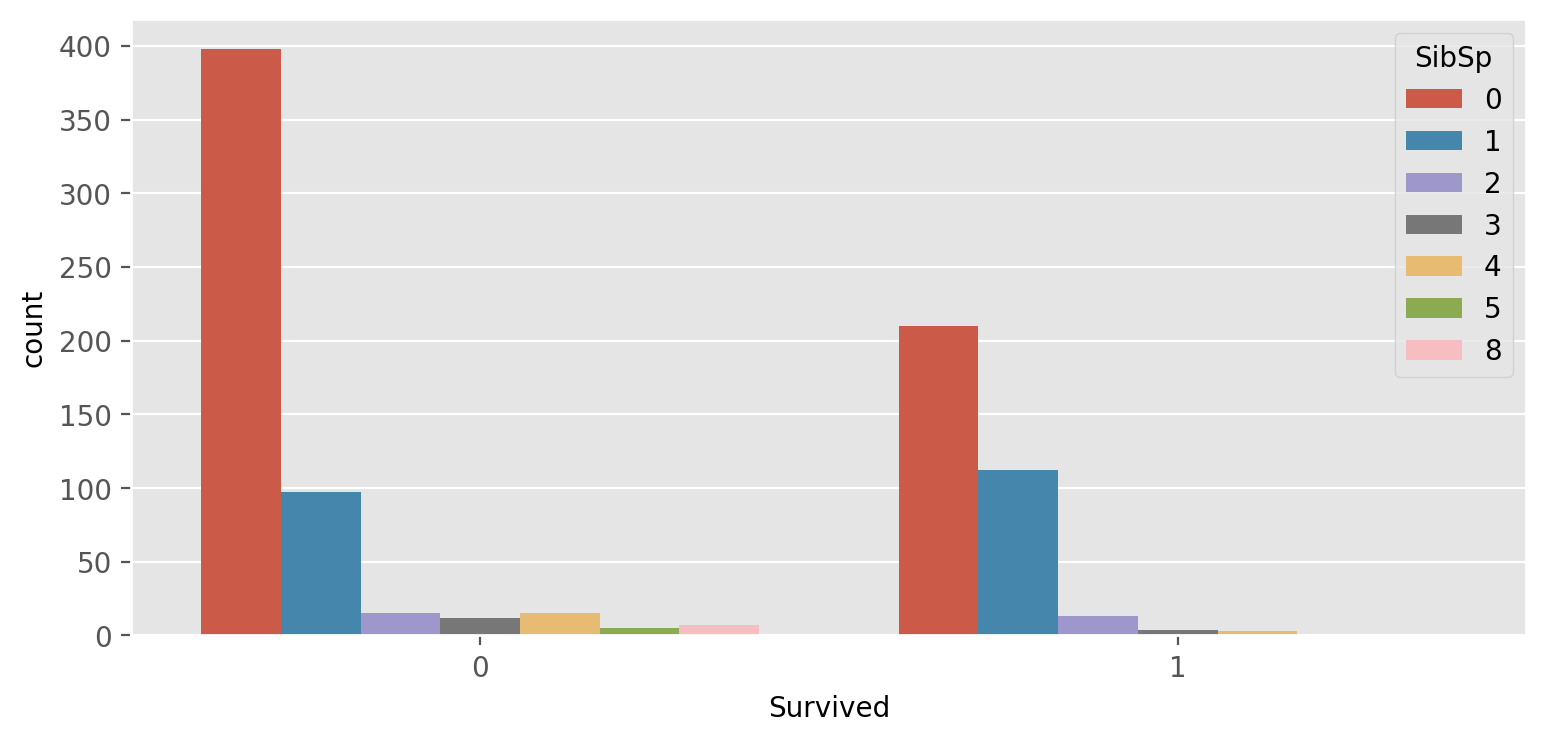

In [22]:
plt.figure(figsize = (9,4), dpi = 200)
sns.countplot(x = 'Survived', hue = 'SibSp', data = df)

<Axes: xlabel='Survived', ylabel='count'>

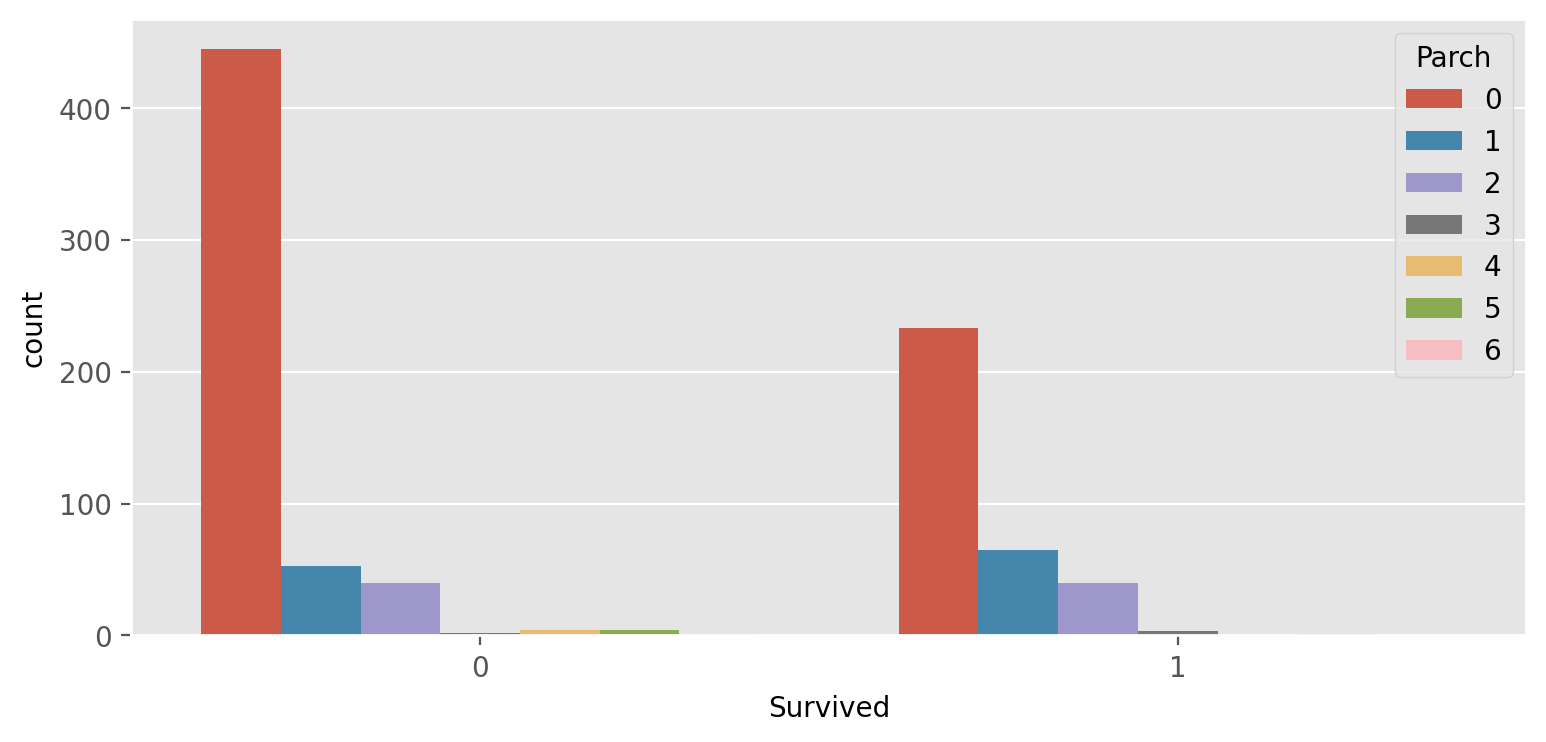

In [23]:
plt.figure(figsize = (9,4), dpi = 200)
sns.countplot(x = 'Survived', hue = 'Parch', data = df)

# -------------------------------------------------------------------------------------------------------

In [24]:
df['Fam_members'] = df['SibSp'] + df['Parch']
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Fam_members
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [25]:
df['Sex'] = df['Sex'].map({'female' : 0, 'male' : 1}).astype(int)
df['Embarked'] = df['Embarked'].map({'S' : 0, 'C' : 1, 'Q' : 2}).astype(int)

In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Fam_members
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,1,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0,0


In [27]:
cols = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Fam_members']
X = df[cols].values
Y = df[['Survived']].values

In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 5)

In [29]:
print('Training Data Shape   : ', x_train.shape)
print('Training Labels Shape : ', y_train.shape)
print('Testing Data Shape    : ', x_test.shape)
print('Testing Labels Shape  : ', y_test.shape)

Training Data Shape   :  (712, 6)
Training Labels Shape :  (712, 1)
Testing Data Shape    :  (179, 6)
Testing Labels Shape  :  (179, 1)


In [30]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(x_train, y_train)

LogisticRegression()

In [31]:
classifier.predict(x_test[:50])

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0], dtype=int64)

In [32]:
print('Training set Accuracy : ', classifier.score(x_train, y_train))
print('Testing set Accuracy  : ', classifier.score(x_test, y_test))

Training set Accuracy :  0.7991573033707865
Testing set Accuracy  :  0.8156424581005587


# ============================================================
### Classification Evaluation Metric

In [33]:
pred_train = classifier.predict(x_train)
pred_test  = classifier.predict(x_test)

In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss

In [35]:
cm = confusion_matrix(y_test, pred_test)
cm

array([[99, 12],
       [21, 47]], dtype=int64)

In [36]:
import itertools
def plot_confusion_matrix(cm, classes,
                         normalize=False,
                         title='Confusion matrix',
                         cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix
    Normalization can be applied by setting 'normalize=True'.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized confusion matrix')
    else:
        print('Confusion matrix without normalization')
        
    #print(cm)
    
    thresh = cm.max() / 2.
    for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
            horizontalalignment='center',
            color='white' if cm[i,j] > thresh else 'black')
        
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('predicted label')

Confusion matrix without normalization


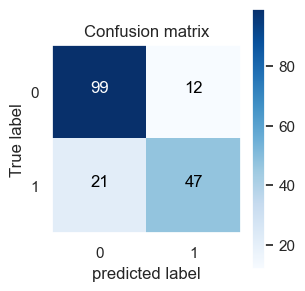

In [37]:
plt.figure(figsize = (3,3), dpi = 100)
sns.set(rc = {'axes.grid' : False})
plot_confusion_matrix(cm, [0,1])

In [38]:
accuracy_score(y_test, pred_test)

0.8156424581005587

In [39]:
(99 + 47) / 179

0.8156424581005587

In [40]:
precision_score(y_test, pred_test)

0.7966101694915254

In [41]:
47 / (47 + 12)

0.7966101694915254

In [42]:
recall_score(y_test, pred_test)

0.6911764705882353

In [43]:
47 / (47 + 21)

0.6911764705882353

In [44]:
f1_score(y_test, pred_test)

0.7401574803149606

In [45]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       111
           1       0.80      0.69      0.74        68

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



In [46]:
from sklearn.metrics import log_loss
log_loss(y_test, pred_test)

6.6449193398931055